# Chapter 1 — Exploratory Data Analysis

**Book:** Practical Statistics for Data Scientists, 2nd Edition  
**Authors:** Peter Bruce, Andrew Bruce, Peter Gedeck

## Chapter Overview

Exploratory Data Analysis (EDA) is the process of examining and
summarizing data before applying statistical models or machine
learning methods.

This chapter introduces techniques for understanding the structure,
location, variability, distribution, and relationships within data.

## 1. Elements of Structured Data

Data can be organized in several different structures. For data
science and predictive modeling, rectangular data is especially
important.

A rectangular dataset consists of:

- **Rows:** records or observations
- **Columns:** variables or features

A pandas DataFrame is a common Python representation of rectangular
data.

Other structures include time series, spatial data, and graph/network
data.

In [1]:
import pandas as pd

data = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [20, 21, 19],
    'Passed': [True, True, False]
})

display(data)

print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

,Name,Age,Passed
0,Alice,20,True
1,Bob,21,True
2,Charlie,19,False


Rows: 3
Columns: 3


### Interpretation

The DataFrame represents rectangular data. Each row represents one
observation, while each column represents a variable.

## 2. Estimates of Location

An estimate of location describes a typical or central value of a
variable.

The main measures discussed in this chapter are the mean, median,
trimmed mean, and weighted mean.

### Mean

The mean is the sum of all observations divided by the number of
observations.

$$
\bar{x} = \frac{\sum_{i=1}^{n}x_i}{n}
$$

The mean uses every observation, so extreme values can strongly
affect it.

In [2]:
import numpy as np

values = np.array([3, 5, 1, 2])

mean = np.mean(values)

print("Values:", values)
print(f"Mean = {mean:.2f}")

Values: [3 5 1 2]
Mean = 2.75


**Interpretation:** The mean is **2.75**. It represents the central
value obtained by averaging all four observations.

### Trimmed Mean and Weighted Mean

A **trimmed mean** removes a fixed number of extreme values from
both ends of the sorted data before calculating the mean.

$$
\bar{x} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n-2p}
$$

A **weighted mean** gives different observations different levels
of importance.

$$
\bar{x}_w =
\frac{\sum_i w_i x_i}{\sum_i w_i}
$$

Trimmed means can reduce the influence of extreme observations,
while weighted means are useful when observations have different
importance.

In [3]:
from scipy import stats

values = np.array([1, 2, 3, 4, 5, 100])

location_summary = pd.Series({
    'Mean': np.mean(values),
    'Trimmed Mean': stats.trim_mean(values, 0.2),
    'Median': np.median(values)
})

display(location_summary.to_frame('Value'))

,Value
Mean,19.166667
Trimmed Mean,3.500000
Median,3.500000


### Interpretation

The ordinary mean is strongly affected by the value 100. The
trimmed mean reduces the influence of this extreme value.

The weighted mean allows some observations to contribute more than
others.

### Median and Robust Estimates

The **median** is the value that separates the data so that half
of the observations are above it and half are below it.

Unlike the mean, the median is relatively resistant to outliers.

An estimate that is not strongly affected by extreme values is
described as **robust**.

In [4]:
values = np.array([1, 2, 3, 4, 100])

comparison = pd.DataFrame({
    'Measure': ['Mean', 'Median'],
    'Value': [np.mean(values), np.median(values)]
})

display(comparison)

,Measure,Value
0,Mean,22.0
1,Median,3.0


### Interpretation

The extreme value 100 greatly increases the mean, while the median
remains close to the center of the majority of the observations.

This demonstrates why the median can be useful when a dataset
contains outliers.

### Example: Location Estimates of Population and Murder Rates

The chapter applies location estimates to state-level population
and murder-rate data.

The population variable is highly uneven across states, making it
useful for comparing different measures of location.

In [5]:
state = pd.read_csv('../data/state.csv')

display(state.head())
print(f"Dataset shape: {state.shape[0]} states × {state.shape[1]} columns")

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


Dataset shape: 50 states × 4 columns


In [6]:
population_location = pd.DataFrame({
    'Estimate': [
        state['Population'].mean(),
        stats.trim_mean(state['Population'], 0.1),
        state['Population'].median()
    ]
}, index=['Mean', '10% Trimmed Mean', 'Median'])

population_location['Estimate'] = population_location['Estimate'].round().astype(int)

display(population_location.style.format({'Estimate': '{:,}'}))

,Estimate
Mean,"6,162,876"
10% Trimmed Mean,"4,783,697"
Median,"4,436,370"


In [7]:
population_location['Difference from Median'] = (
    population_location['Estimate'] - state['Population'].median()
)

display(
    population_location.style.format({
        'Estimate': '{:,}',
        'Difference from Median': '{:+,}'
    })
)

,Estimate,Difference from Median
Mean,"6,162,876","+1,726,506.5"
10% Trimmed Mean,"4,783,697","+347,327.5"
Median,"4,436,370",+0.5


In [8]:
population_location['Relative to Median (%)'] = (
    population_location['Estimate'] / state['Population'].median() - 1
) * 100

display(
    population_location.style.format({
        'Estimate': '{:,}',
        'Difference from Median': '{:+,}',
        'Relative to Median (%)': '{:+.1f}%'
    })
)

,Estimate,Difference from Median,Relative to Median (%)
Mean,"6,162,876","+1,726,506.5",+38.9%
10% Trimmed Mean,"4,783,697","+347,327.5",+7.8%
Median,"4,436,370",+0.5,+0.0%


### Interpretation

The mean, median, and trimmed mean provide different descriptions
of the typical state population.

The difference between them illustrates how a few states with very
large populations can influence the mean.

In [9]:
import wquantiles

weighted_location = pd.Series({
    'Weighted Mean Murder Rate': np.average(
        state['Murder.Rate'],
        weights=state['Population']
    ),
    'Weighted Median Murder Rate': wquantiles.median(
        state['Murder.Rate'],
        weights=state['Population']
    )
})

display(weighted_location.to_frame('Murder Rate'))

,Murder Rate
Weighted Mean Murder Rate,4.445834
Weighted Median Murder Rate,4.400000


## 3. Estimates of Variability

Variability, also called dispersion, describes how spread out the
observations are around a central value.

Important measures of variability include:

- Variance
- Standard deviation
- Mean absolute deviation (MAD)
- Median absolute deviation from the median
- Range
- Percentiles
- Interquartile range (IQR)

Measures based on squared deviations, such as variance and standard
deviation, are sensitive to outliers.

### Standard Deviation

The deviation of an observation is its difference from the mean.

The sample variance is:

$$
s^2 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

The standard deviation is the square root of the variance:

$$
s = \sqrt{s^2}
$$

Standard deviation is easier to interpret than variance because it
uses the same units as the original data.

In [10]:
values = np.array([1, 4, 4])

mean = np.mean(values)
variance = np.var(values, ddof=1)
standard_deviation = np.std(values, ddof=1)

variability = pd.Series({
    'Mean': mean,
    'Variance': variance,
    'Standard Deviation': standard_deviation
})

display(variability.to_frame('Value'))

,Value
Mean,3.000000
Variance,3.000000
Standard Deviation,1.732051


### Interpretation

The standard deviation summarizes the typical spread of observations
around the mean. A larger standard deviation indicates greater
variability.

The `ddof=1` argument calculates the sample standard deviation,
corresponding to the book's use of $n-1$ in the sample variance
formula.

### Mean Absolute Deviation and Median Absolute Deviation

The **mean absolute deviation** calculates the average absolute
distance from the mean:

$$
MAD_{mean} =
\frac{\sum_{i=1}^{n}|x_i-\bar{x}|}{n}
$$

The **median absolute deviation from the median** first calculates
the median and then takes the median of the absolute deviations:

$$
MAD =
\operatorname{Median}(|x_i-m|)
$$

where $m$ is the median.

The median absolute deviation is more resistant to extreme values
than standard deviation.

In [11]:
from statsmodels.robust.scale import mad

values = np.array([1, 4, 4, 5, 100])

mean_absolute_deviation = np.mean(
    np.abs(values - np.mean(values))
)

median_absolute_deviation = mad(values)

robust_summary = pd.Series({
    'Mean Absolute Deviation': mean_absolute_deviation,
    'Median Absolute Deviation': median_absolute_deviation
})

display(robust_summary.to_frame('Value'))

,Value
Mean Absolute Deviation,30.880000
Median Absolute Deviation,1.482602


### Interpretation

The extreme value of 100 has a strong effect on the standard
deviation. Measures based on absolute deviations, particularly the
median absolute deviation, are more resistant to extreme values.

### Percentiles and Interquartile Range

A percentile describes the value below which a given percentage of
the observations falls.

For example:

- 25th percentile = first quartile
- 50th percentile = median
- 75th percentile = third quartile

The interquartile range is:

$$
IQR = Q_{75} - Q_{25}
$$

The IQR focuses on the middle 50% of the data and is less sensitive
to extreme values than the range.

In [12]:
values = np.array([3, 1, 5, 3, 6, 7, 2, 9])

percentiles = pd.Series({
    '25th Percentile': np.quantile(values, 0.25),
    '50th Percentile (Median)': np.quantile(values, 0.50),
    '75th Percentile': np.quantile(values, 0.75)
})

iqr = percentiles['75th Percentile'] - percentiles['25th Percentile']

display(percentiles.to_frame('Value'))
print(f"IQR = {iqr:.2f}")

,Value
25th Percentile,2.75
50th Percentile (Median),4.00
75th Percentile,6.25


IQR = 3.50


### Interpretation

The IQR measures the spread of the middle 50% of observations.
Unlike the range, it is less affected by the smallest and largest
values.

In [13]:
population_variability = pd.Series({
    'Standard Deviation': state['Population'].std(),
    'IQR': (
        state['Population'].quantile(0.75)
        - state['Population'].quantile(0.25)
    ),
    'Median Absolute Deviation': mad(state['Population'])
})

display(population_variability.to_frame('Value').style.format('{:,.0f}'))

,Value
Standard Deviation,"6,848,235"
IQR,"4,847,308"
Median Absolute Deviation,"3,849,876"


In [14]:
variability_comparison = pd.DataFrame({
    'Measure': population_variability.index,
    'Value': population_variability.values,
    'Relative to SD (%)': (
        population_variability.values
        / population_variability['Standard Deviation']
        * 100
    )
})

display(
    variability_comparison.style.format({
        'Value': '{:,.0f}',
        'Relative to SD (%)': '{:.1f}%'
    })
)

,Measure,Value,Relative to SD (%)
0,Standard Deviation,"6,848,235",100.0%
1,IQR,"4,847,308",70.8%
2,Median Absolute Deviation,"3,849,876",56.2%


In [15]:
print("Most robust measures:")
display(
    variability_comparison[
        variability_comparison['Measure'] != 'Standard Deviation'
    ].style.format({
        'Value': '{:,.0f}',
        'Relative to SD (%)': '{:.1f}%'
    })
)

Most robust measures:


,Measure,Value,Relative to SD (%)
1,IQR,"4,847,308",70.8%
2,Median Absolute Deviation,"3,849,876",56.2%


### Interpretation

The three measures describe the variability of state populations
from different perspectives.

Standard deviation is strongly affected by the states with unusually
large populations, while the IQR and MAD are more resistant to such
extreme values.

This illustrates why it can be useful to use both conventional and
robust measures of variability.

## 4. Exploring the Data Distribution

Location and variability summarize data using a small number of
statistics, but they do not show the complete shape of a
distribution.

Visualizations allow us to examine:

- the center of the distribution
- the spread of the data
- skewness
- possible outliers
- the overall shape of the distribution

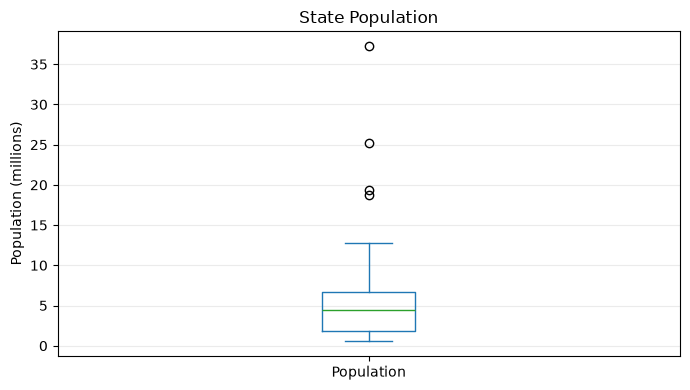

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

(state['Population'] / 1_000_000).plot.box(ax=ax)

ax.set_title('State Population')
ax.set_ylabel('Population (millions)')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows the median, the middle 50% of the observations,
and potential extreme values.

For the state population data, the distribution contains several
high-population states that appear as outliers.

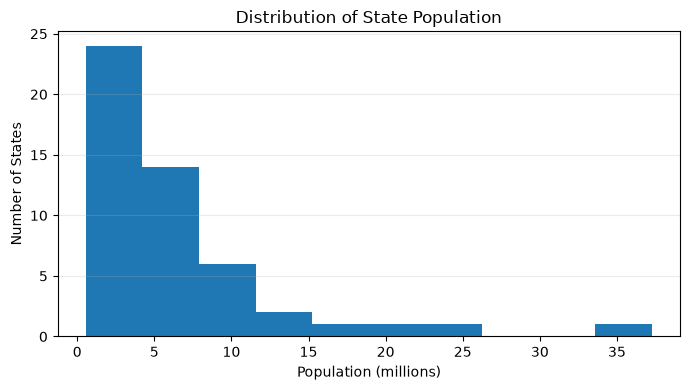

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

(state['Population'] / 1_000_000).plot.hist(
    bins=10,
    ax=ax
)

ax.set_title('Distribution of State Population')
ax.set_xlabel('Population (millions)')
ax.set_ylabel('Number of States')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The histogram shows how frequently state populations occur within
different population ranges.

The distribution is not symmetric because a relatively small number
of states have much larger populations than most other states.

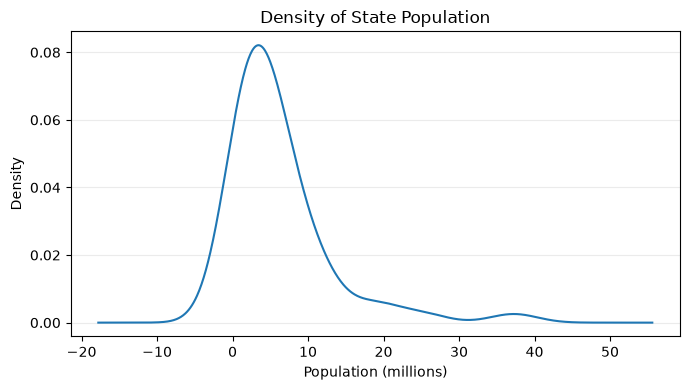

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

(state['Population'] / 1_000_000).plot.density(
    ax=ax
)

ax.set_title('Density of State Population')
ax.set_xlabel('Population (millions)')
ax.set_ylabel('Density')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The density plot provides a smoothed view of the distribution.
Together with the histogram and boxplot, it gives a clearer picture
of the shape, spread, and unusual values in the data.

In [19]:
murder_percentiles = state['Murder.Rate'].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

murder_percentiles.index = [
    '5th', '25th', '50th (Median)', '75th', '95th'
]

display(
    murder_percentiles.to_frame('Murder Rate')
    .style.format('{:.2f}')
)

,Murder Rate
5th,1.60
25th,2.42
50th (Median),4.00
75th,5.55
95th,6.51


### Interpretation

The median murder rate is 4 per 100,000 people.

The 5th percentile is about 1.6, while the 95th percentile is about
6.51, showing the amount of variation across states.

## 5. Exploring Binary and Categorical Data

Not all variables are numeric.

Categorical variables represent groups or categories. A binary
variable is a categorical variable with two possible outcomes.

Examples include:

- Yes / No
- Pass / Fail
- Male / Female
- Treatment / Control

Categorical data can be summarized using counts, proportions, and
the mode.

,Count
Category,
A,4
B,2
C,1


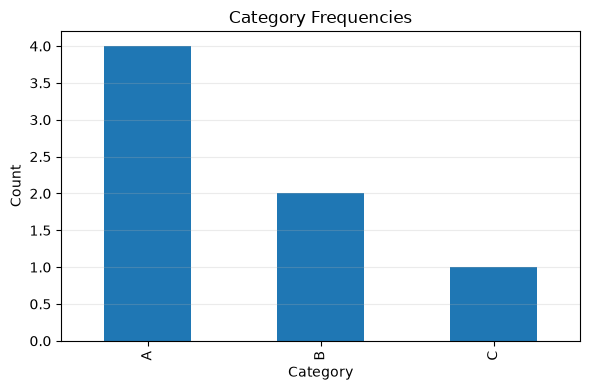

In [20]:
category = pd.Series([
    'A', 'B', 'A', 'C', 'A', 'B', 'A'
], name='Category')

category_counts = category.value_counts()

display(
    category_counts.to_frame('Count')
)

fig, ax = plt.subplots(figsize=(6, 4))

category_counts.sort_index().plot.bar(ax=ax)

ax.set_title('Category Frequencies')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Mode

The **mode** is the most frequently occurring category.

In this example, category `A` occurs most often, so it is the mode.

In [21]:
mode = category.mode()

print("Mode:", ", ".join(mode.astype(str)))
print(f"Frequency of mode: {(category == mode.iloc[0]).sum()}")

Mode: A
Frequency of mode: 4


### Expected Value

For a discrete random variable, the expected value is:

$$
E(X) = \sum_x xP(X=x)
$$

It represents the long-run average outcome when the probabilities
of the possible outcomes are taken into account.

In [22]:
values = np.array([0, 1])
probabilities = np.array([0.7, 0.3])

expected_value = np.sum(values * probabilities)

expected_value_table = pd.DataFrame({
    'Outcome': values,
    'Probability': probabilities,
    'Weighted Outcome': values * probabilities
})

display(
    expected_value_table.style.format({
        'Probability': '{:.1f}',
        'Weighted Outcome': '{:.2f}'
    })
)

print(f"Expected Value = {expected_value:.2f}")

,Outcome,Probability,Weighted Outcome
0,0,0.7,0.00
1,1,0.3,0.30


Expected Value = 0.30


### Interpretation

The expected value is 0.3 because the outcome `1` has probability
0.3 while the outcome `0` has probability 0.7.

### Probability

Probability describes how likely an event is to occur.

For a binary event, the probabilities of the two possible outcomes
must add up to 1.

For example:

$$
P(\text{success}) + P(\text{failure}) = 1
$$

In [23]:
probabilities = pd.Series({
    'Success': 0.3,
    'Failure': 0.7
})

display(
    probabilities.to_frame('Probability')
    .style.format('{:.1f}')
)

print(f"Total probability = {probabilities.sum():.1f}")

,Probability
Success,0.3
Failure,0.7


Total probability = 1.0


### Interpretation

The probabilities sum to 1, representing all possible outcomes of
the binary event.

## 6. Correlation

Correlation measures the extent to which two numeric variables are
associated with one another.

- **Positive correlation:** high values of one variable tend to occur
  with high values of the other.
- **Negative correlation:** high values of one variable tend to occur
  with low values of the other.
- **Zero correlation:** there is no linear association.

The Pearson correlation coefficient ranges from -1 to +1.

### Pearson Correlation Coefficient

Pearson's correlation coefficient is calculated as:

$$
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
(n-1)s_xs_y
}
$$

A value close to +1 indicates a strong positive linear association,
while a value close to -1 indicates a strong negative linear
association.

Correlation does not necessarily describe nonlinear relationships.

In [25]:
correlation = np.corrcoef(x, y)[0, 1]

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 1.000


### Interpretation

The correlation is +1, indicating a perfect positive linear
relationship. As `x` increases, `y` increases proportionally.

### Correlation Matrix

When several numeric variables are available, calculating the
correlation between every pair produces a correlation matrix.

The diagonal contains 1 because every variable is perfectly
correlated with itself.

In [26]:
numeric_state = state[
    ['Population', 'Murder.Rate']
]

correlation_matrix = numeric_state.corr()

display(
    correlation_matrix.style.format('{:.3f}')
)

,Population,Murder.Rate
Population,1.000,0.182
Murder.Rate,0.182,1.000


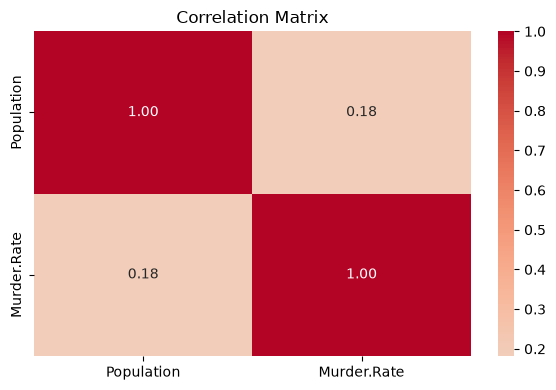

In [27]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)

ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Interpretation

The heatmap provides a visual representation of the correlation
matrix. Positive and negative associations can be identified from
the sign and magnitude of the correlation coefficients.

### Scatterplots

A scatterplot displays the relationship between two numeric variables.

Each point represents one observation:

- The x-axis represents one variable.
- The y-axis represents another variable.

Scatterplots are useful for seeing patterns that may not be obvious
from a correlation coefficient alone.

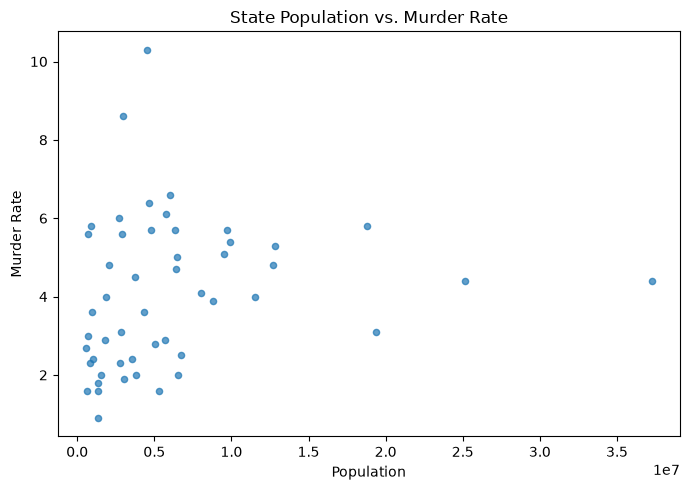

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))

state.plot.scatter(
    x='Population',
    y='Murder.Rate',
    alpha=0.7,
    ax=ax
)

ax.set_title('State Population vs. Murder Rate')
ax.set_xlabel('Population')
ax.set_ylabel('Murder Rate')

plt.tight_layout()
plt.show()

### Interpretation

The scatterplot allows the relationship between population and
murder rate to be examined visually.

The points do not form a clear straight-line pattern, illustrating
why the scatterplot should be considered alongside the numerical
correlation rather than relying on the coefficient alone.

## 7. Exploring Two or More Variables

When analyzing multiple variables, the appropriate method depends on
the types of variables being compared.

For two numeric variables, scatterplots are useful for smaller
datasets. For very large datasets, however, a scatterplot can become
too dense to interpret.

The chapter introduces **hexagonal binning** and **contour plots**
as alternatives for visualizing the density of observations.

In [30]:
# Load the King County property-tax dataset.
# The provided dataset is compressed as a gzip CSV file.

kc_tax = pd.read_csv(
    '../data/kc_tax.csv.gz',
    compression='gzip'
)

print(f"Original records: {len(kc_tax):,}")
print(f"Columns: {kc_tax.shape[1]}")

display(kc_tax.head())

Original records: 498,249
Columns: 3


,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


The dataset contains three variables used in this chapter:

- `TaxAssessedValue`: the tax-assessed value of the property
- `SqFtTotLiving`: the finished living area in square feet
- `ZipCode`: the property's ZIP code

The original dataset contains observations outside the range needed for
the visualization, including extremely large properties and very high
assessed values.

In [33]:
# Filter the dataset to the range used in the book.
#
# Only properties satisfying all three conditions are retained:
#   1. Tax-assessed value is below $750,000
#   2. Finished living area is greater than 100 square feet
#   3. Finished living area is less than 3,500 square feet

kc_tax0 = kc_tax.loc[
    (kc_tax['TaxAssessedValue'] < 750000) &
    (kc_tax['SqFtTotLiving'] > 100) &
    (kc_tax['SqFtTotLiving'] < 3500)
].copy()

filter_summary = pd.Series({
    'Original records': len(kc_tax),
    'Filtered records': len(kc_tax0),
    'Records removed': len(kc_tax) - len(kc_tax0)
})

display(
    filter_summary
    .to_frame('Count')
    .style.format('{:,}')
)

,Count
Original records,"498,249"
Filtered records,"432,693"
Records removed,"65,556"


In [34]:
# Verify that the filtered data falls within the required ranges.

kc_tax0_summary = pd.DataFrame({
    'Minimum': [
        kc_tax0['SqFtTotLiving'].min(),
        kc_tax0['TaxAssessedValue'].min()
    ],
    'Maximum': [
        kc_tax0['SqFtTotLiving'].max(),
        kc_tax0['TaxAssessedValue'].max()
    ]
}, index=[
    'Finished Square Feet',
    'Tax-Assessed Value'
])

display(kc_tax0_summary)

,Minimum,Maximum
Finished Square Feet,111.0,3499.0
Tax-Assessed Value,2000.0,749000.0


The filtering step produces 432,693 observations. The resulting data
contains properties with finished living areas between 111 and 3,499
square feet and tax-assessed values between $2,000 and $749,000.

This filtered dataset, `kc_tax0`, is used for the following
visualizations.

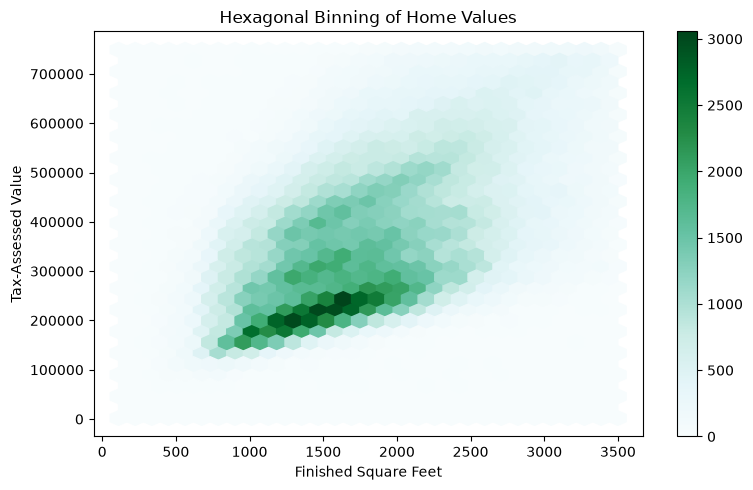

In [35]:
# Hexagonal binning groups nearby observations into hexagons.
# The color intensity represents the number of observations
# within each hexagonal region.

fig, ax = plt.subplots(figsize=(8, 5))

kc_tax0.plot.hexbin(
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    gridsize=30,
    sharex=False,
    ax=ax
)

ax.set_title('Hexagonal Binning of Home Values')
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

plt.tight_layout()
plt.show()

### Interpretation

The hexagonal binning plot summarizes the density of properties based on
their finished living area and tax-assessed value.

Each hexagon represents a region of the two-dimensional data space, and
the color intensity indicates how many observations fall within that
region.

This visualization is useful when a scatterplot would contain too many
overlapping points.

### 7.2 Contour Plot

A contour plot provides another way to visualize the density of two
numeric variables.

Instead of displaying individual observations or hexagonal regions,
a contour plot draws lines connecting locations with similar estimated
density.

The result is similar to a topographical map, where each contour
represents a particular level of data density.

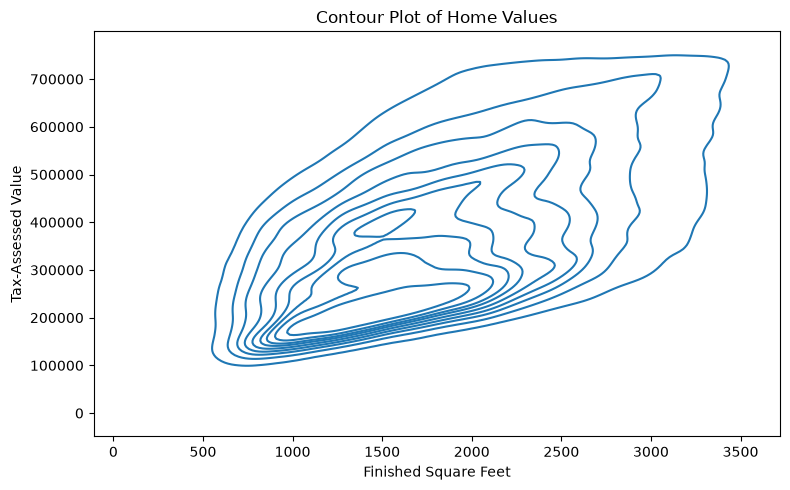

In [39]:
# Estimate the two-dimensional density of living area and
# tax-assessed value using a kernel density estimate.

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=kc_tax0,
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    levels=10,
    ax=ax
)

ax.set_title('Contour Plot of Home Values')
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

plt.tight_layout()
plt.show()

### Interpretation

The contour lines represent areas with similar estimated data density.
Closely concentrated contour lines indicate regions where the density
changes rapidly, while the overall shape of the contours provides a
view of the relationship between living area and assessed value.

Contour plots are particularly useful when the dataset contains many
observations and individual points would make the relationship difficult
to see.

### 7.3 Two Categorical Variables

When two variables are categorical, a contingency table can be used to
summarize their relationship.

A contingency table counts the number of observations belonging to each
combination of categories.

The book demonstrates this approach using Lending Club loan data, where
loan grade and loan status are categorical variables.

In [40]:
# Load the Lending Club loan dataset.

lc_loans = pd.read_csv('../data/lc_loans.csv')

print(f"Number of records: {len(lc_loans):,}")

display(lc_loans.head())

Number of records: 450,961


,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [41]:
# Count the number of loans for each combination
# of loan grade and loan status.

loan_table = pd.crosstab(
    lc_loans['grade'],
    lc_loans['status']
)

display(loan_table)

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,1562,50051,20408,469
B,5302,93852,31160,2056
C,6023,88928,23147,2777
D,5007,53281,13681,2308
E,2842,24639,5949,1374
F,1526,8444,2328,606
G,409,1990,643,199


The contingency table contains raw counts. However, the number of loans
may differ substantially between grades, so comparing raw counts alone
can be misleading.

Row percentages provide a way to compare the distribution of loan
statuses within each grade.

In [42]:
# Calculate the percentage distribution of loan status
# within each loan grade.

loan_percentages = (
    pd.crosstab(
        lc_loans['grade'],
        lc_loans['status'],
        normalize='index'
    ) * 100
)

display(
    loan_percentages.style.format('{:.1f}%')
)

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,2.2%,69.0%,28.2%,0.6%
B,4.0%,70.9%,23.5%,1.6%
C,5.0%,73.6%,19.1%,2.3%
D,6.7%,71.7%,18.4%,3.1%
E,8.2%,70.8%,17.1%,3.9%
F,11.8%,65.4%,18.0%,4.7%
G,12.6%,61.4%,19.8%,6.1%


### Interpretation

The contingency table shows the number of loans belonging to each
combination of grade and status.

The row-percentage table instead shows the relative distribution of loan
statuses within each grade. This makes it easier to compare grades even
when the total number of loans differs between them.

### 7.4 Categorical and Numeric Data

When one variable is categorical and another is numeric, we can compare
the distribution of the numeric variable across the different
categories.

Boxplots are useful for this purpose because they display the median,
quartiles, overall spread, and potential outliers.

The book demonstrates this using airline delay statistics.

In [44]:
# Load the airline delay dataset.

airline_stats = pd.read_csv('../data/airline_stats.csv')

print(f"Number of records: {len(airline_stats):,}")

display(airline_stats.head())

Number of records: 33,468


,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


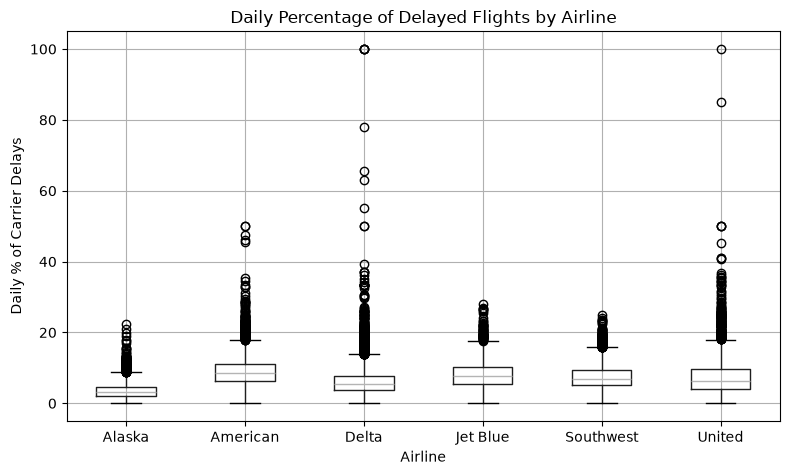

In [45]:
# Compare the distribution of daily carrier delays
# between different airlines.

fig, ax = plt.subplots(figsize=(8, 5))

airline_stats.boxplot(
    by='airline',
    column='pct_carrier_delay',
    ax=ax
)

ax.set_title('Daily Percentage of Delayed Flights by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Daily % of Carrier Delays')

# Remove pandas' automatically generated super-title.
plt.suptitle('')

plt.tight_layout()
plt.show()

### Interpretation

The boxplot allows the distributions of delay percentages to be
compared between airlines.

The center of each box represents the median, while the box represents
the interquartile range. Values outside the usual range are displayed
as potential outliers.

This allows differences in both the center and spread of the delay
distributions to be examined.

#### Violin Plot

A violin plot provides additional information about the distribution of
a numeric variable within each category.

Unlike a basic boxplot, a violin plot also displays the estimated density
of the observations, making the shape of the distribution easier to
observe.

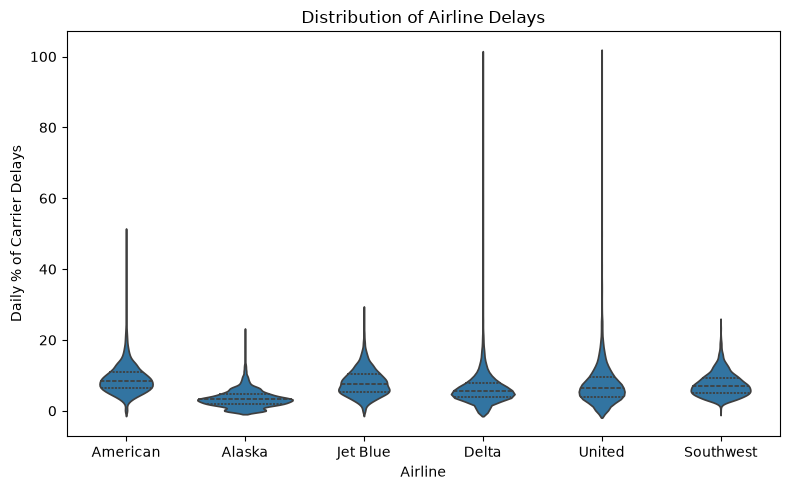

In [46]:
# Display the distribution of carrier delays for each airline.
# The quartiles are shown inside each violin.

fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=airline_stats,
    x='airline',
    y='pct_carrier_delay',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribution of Airline Delays')
ax.set_xlabel('Airline')
ax.set_ylabel('Daily % of Carrier Delays')

plt.tight_layout()
plt.show()

### Interpretation

The violin plot shows the shape and density of the delay distribution
for each airline.

The wider portions of a violin indicate regions where observations are
more concentrated. The quartile markers also provide information about
the central portion of the distribution.

Compared with a boxplot, the violin plot provides more information about
the shape of the distribution.

### 7.5 Visualizing Multiple Variables

When more than two variables are analyzed simultaneously, important
relationships can become hidden when all observations are displayed in
one plot.

One solution is to use a conditioning variable. The data can be divided
into separate plots according to the value of another variable.

For the King County housing data, ZIP code can be used as a conditioning
variable while the relationship between finished living area and
tax-assessed value is examined.

This allows relationships in different geographic areas to be compared
separately.

In [47]:
# Select several ZIP codes for comparison.

selected_zipcodes = [98188, 98105, 98108, 98126]

kc_tax_subset = kc_tax0[
    kc_tax0['ZipCode'].isin(selected_zipcodes)
].copy()

# ZIP codes are categorical identifiers, so convert them to integers
# for cleaner labels in the visualization.
kc_tax_subset['ZipCode'] = kc_tax_subset['ZipCode'].astype(int)

print(f"Selected records: {len(kc_tax_subset):,}")

display(
    kc_tax_subset['ZipCode']
    .value_counts()
    .sort_index()
    .to_frame('Records')
)

Selected records: 19,690


,Records
ZipCode,
98105,4481
98108,5535
98126,5631
98188,4043


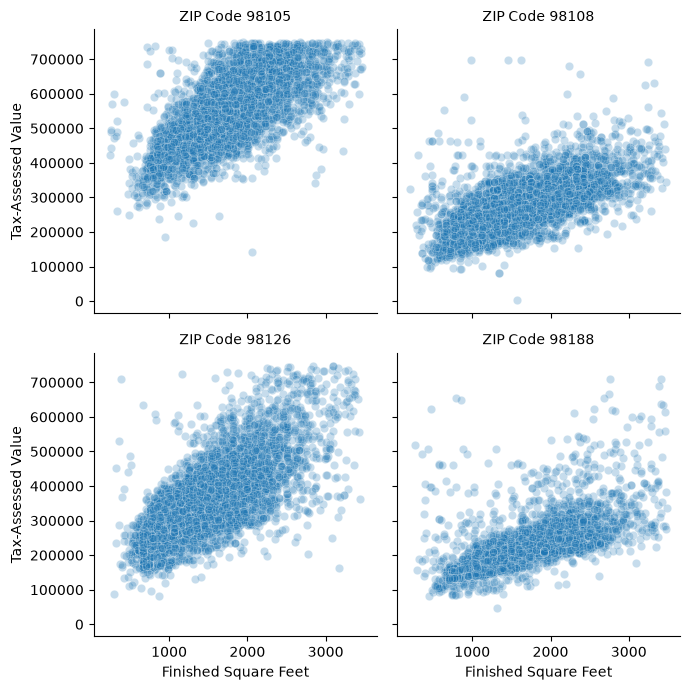

In [48]:
# Create a separate scatterplot for each ZIP code.
# The same x- and y-axis scales are used so that the
# distributions can be compared directly.

g = sns.FacetGrid(
    kc_tax_subset,
    col='ZipCode',
    col_wrap=2,
    height=3.5,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    alpha=0.25
)

g.set_axis_labels(
    'Finished Square Feet',
    'Tax-Assessed Value'
)

g.set_titles('ZIP Code {col_name}')

plt.tight_layout()
plt.show()

### Interpretation

The faceted scatterplots separate the properties according to ZIP code.

Using the same axes across the plots makes it possible to compare the
relationship between finished living area and tax-assessed value across
different locations.

This demonstrates how adding a conditioning variable can reveal
differences that may be hidden when all observations are displayed in a
single plot.### Interpretation

The faceted scatterplots separate the properties according to ZIP code.

Using the same axes across the plots makes it possible to compare the
relationship between finished living area and tax-assessed value across
different locations.

This demonstrates how adding a conditioning variable can reveal
differences that may be hidden when all observations are displayed in a
single plot.

# Chapter 1 Summary

Exploratory Data Analysis (EDA) is the process of examining data using
numerical summaries and visualizations before performing more advanced
statistical analysis or machine learning.

This chapter introduced several important techniques:

- Structured and rectangular data
- Estimates of location, including the mean and median
- Robust estimates of location
- Estimates of variability, including standard deviation and IQR
- Percentiles and distributions
- Boxplots, histograms, and density plots
- Binary and categorical data
- Expected value and probability
- Correlation and scatterplots
- Hexagonal binning
- Contour plots
- Contingency tables
- Boxplots and violin plots for categorical and numeric variables
- Conditioning and faceting for multiple variables

The central idea of exploratory data analysis is to understand the
structure, distribution, variability, and relationships within a dataset
before applying more advanced statistical or machine-learning methods.

The techniques introduced in this chapter provide the foundation for
the statistical and machine-learning methods discussed in later
chapters.